# 03 · Double DQN y meta aleatoria — hacia el trabajo futuro

**Curso MIA-204 · Trabajo final · Deep RL**

Dos preguntas abiertas que exploramos aquí:

1. **¿Ayuda Double DQN?** DQN usa `max` para el objetivo → sobreestima → los valores Q
   pueden **divergir**. Double DQN separa quién elige y quién valora la acción, para
   reducir esa sobreestimación.
2. **¿Y si la meta también es aleatoria?** (goal-conditioned). Es la versión difícil:
   aquí mostramos que DQN **diverge** en ese caso — el motivo por el que nuestra
   solución principal (notebook 01) usa meta fija, y por qué esto queda como trabajo
   futuro con métodos más robustos.

Mismo entorno y agente que los notebooks 01 y 02 (código común).

In [1]:
# ── Setup: montar Google Drive e importar el código común ──
# Sube la carpeta proyecto-rl/ a tu Drive. Ajusta RUTA si la pusiste en otro lado.
import sys
# Ruta del código común (carpeta dqn/ en tu Drive). Cámbiala si la mueves.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    RUTA = '/content/drive/Othercomputers/My Mac/dqn'
except ImportError:
    RUTA = '.'   # ejecución local desde la carpeta dqn/
sys.path.insert(0, RUTA)
print('RUTA del código común:', RUTA)

try:
    import rasterio
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', '-q', 'rasterio'])

import numpy as np, torch
import matplotlib.pyplot as plt
from entorno_drl import TerrenoDRLEnv, NUM_ACCIONES
from dqn import AgenteDQN
from train import entrenar, evaluar, pares_de_evaluacion, suavizar
from baselines import dijkstra, ruta_greedy, costo_camino, brecha_vs_dijkstra
from datos import ruta_dem
import viz

device = 'cuda' if torch.cuda.is_available() else 'cpu'
SEMILLA = 42
np.random.seed(SEMILLA); torch.manual_seed(SEMILLA)
RUTA_DEM = ruta_dem(RUTA)
print('dispositivo:', device, '| DEM:', RUTA_DEM)

Mounted at /content/drive
RUTA del código común: /content/drive/Othercomputers/My Mac/dqn
dispositivo: cuda | DEM: /content/drive/Othercomputers/My Mac/dqn/dem.tif


## 0 · El terreno (mismo mapa real que el notebook 01)

Recordatorio del entorno: elevación y pendiente del recorte del Misti, y lo que ve
el agente (parche local 9×9 + vector a la meta). El código del entorno es común.

Mapa 108x108 | meta fija en (np.int64(104), np.int64(104)) | obs = 83 números


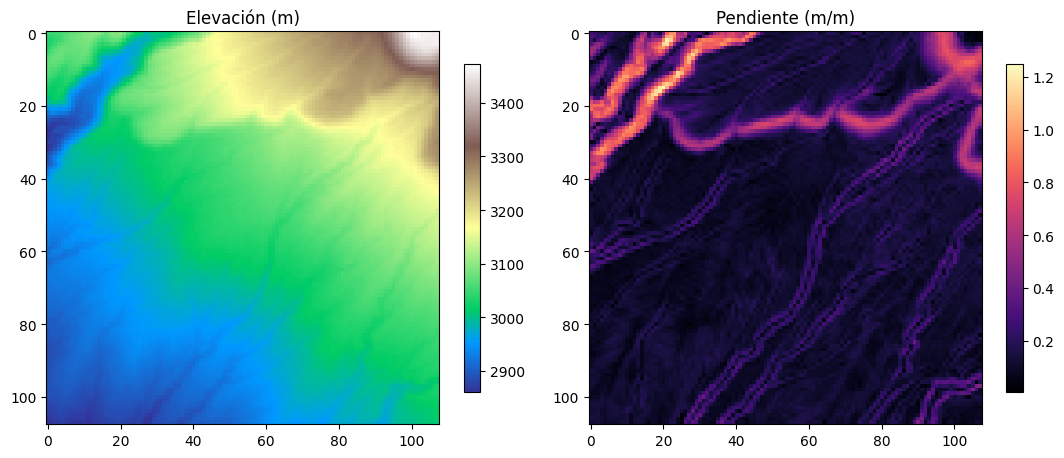

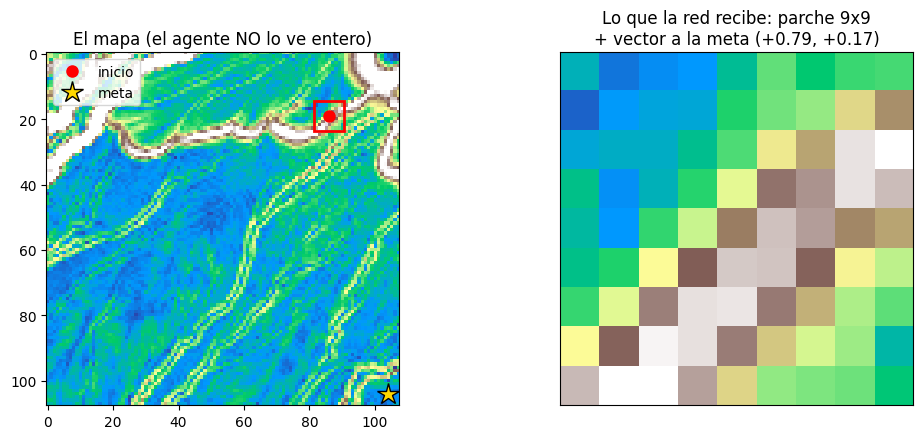

In [2]:
env = TerrenoDRLEnv(RUTA_DEM, semilla=SEMILLA)
print(f'Mapa {env.filas}x{env.columnas} | meta fija en {env.meta_fija} | obs = {env.dim_obs} números')
viz.mapa_terreno(env); plt.show()
viz.que_ve_el_agente(env); plt.show()

## 1 · DQN vs Double DQN (meta fija)

Con meta fija, DQN ya es estable, así que aquí Double DQN es una comparación: ¿converge
más rápido o más alto?

── DQN ──
── Double DQN ──


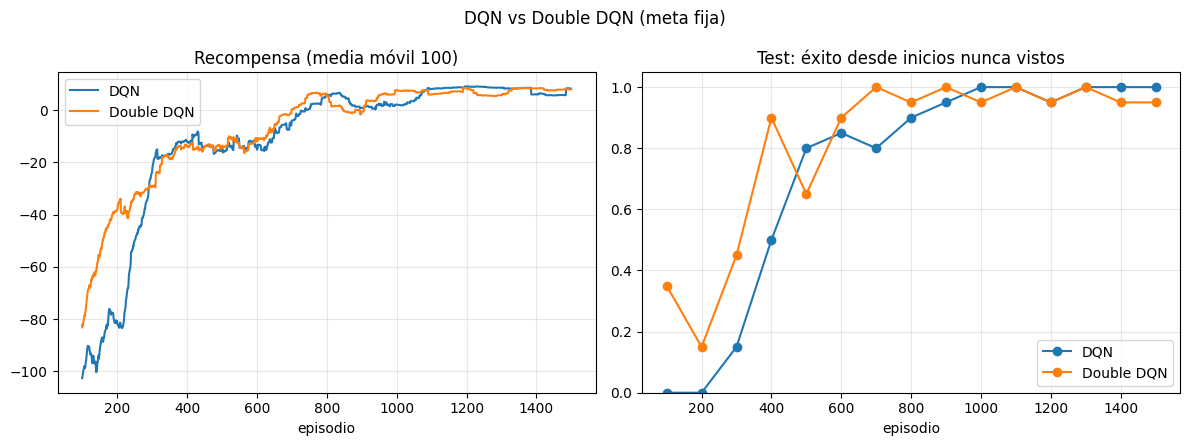

In [ ]:
EPISODIOS = 1500
res = {}
for nombre, doble in [('DQN', False), ('Double DQN', True)]:
    print(f'── {nombre} ──')
    e = TerrenoDRLEnv(RUTA_DEM, semilla=SEMILLA)
    a = AgenteDQN(e.dim_obs, NUM_ACCIONES, device=device, semilla=SEMILLA, doble=doble)
    res[nombre] = entrenar(e, a, EPISODIOS, eval_cada=100, verbose=True)
viz.comparar_curvas(list(res.values()), list(res.keys()),
                    'DQN vs Double DQN (meta fija)'); plt.show()

## 2 · La versión difícil: meta ALEATORIA → divergencia

Ahora la meta cambia cada episodio (`meta_fija=False`). Medimos la magnitud media de los
valores Q, `|Q|`: si explota, es divergencia. Esto reproduce lo que nos llevó a elegir
meta fija en el notebook 01.

ep  200 | test  10% | |Q|    1.39
ep  400 | test   5% | |Q|    3.76
ep  600 | test   0% | |Q|    5.20
ep  800 | test   5% | |Q|    6.89
ep 1000 | test   5% | |Q|    8.50
ep 1200 | test   0% | |Q|   77.51
ep 1400 | test   0% | |Q|  704.10
ep 1600 | test   0% | |Q| 2435.33


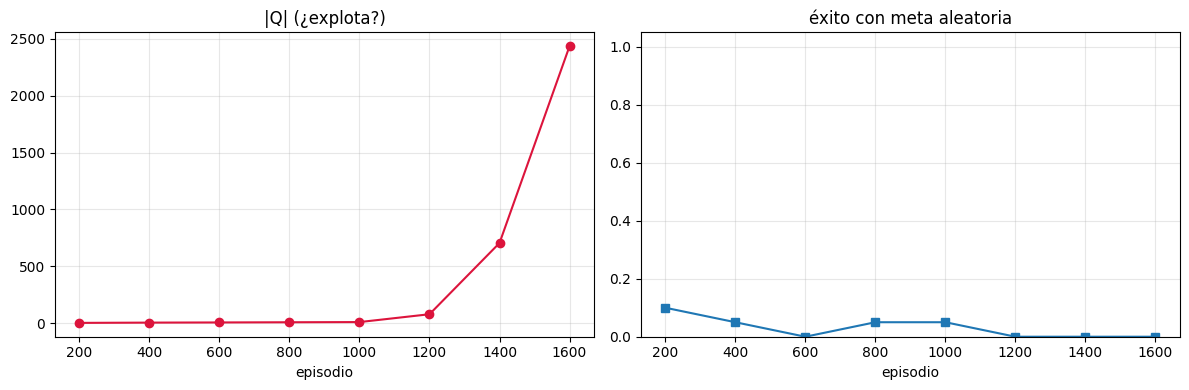

In [4]:
def q_medio(agente, env):
    if len(agente.buffer) < 64:
        return 0.0
    obs, _, _, _, _ = agente.buffer.muestrear(64)
    with torch.no_grad():
        return float(agente.red(obs.to(device)).abs().mean().item())

env_r = TerrenoDRLEnv(RUTA_DEM, meta_fija=False, semilla=SEMILLA)
ag_r = AgenteDQN(env_r.dim_obs, NUM_ACCIONES, device=device, semilla=SEMILLA)
pares_r = pares_de_evaluacion(env_r)

eps_hist, q_hist, ex_hist = [], [], []
paso = 0
for ep in range(1, 1601):
    obs = env_r.reset(); fin = False
    while not fin:
        e = max(0.05, 1.0 - paso/150000)
        a = ag_r.elegir_accion(obs, e)
        obs2, r, fin, ll = env_r.step(a)
        ag_r.observar_y_entrenar(obs, a, r, obs2, fin and ll)
        obs = obs2; paso += 1
    if ep % 200 == 0:
        ex, _ = evaluar(env_r, ag_r, pares_r)
        eps_hist.append(ep); q_hist.append(q_medio(ag_r, env_r)); ex_hist.append(ex)
        print(f'ep {ep:4d} | test {ex:4.0%} | |Q| {q_hist[-1]:7.2f}')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(eps_hist, q_hist, 'o-', color='crimson'); a1.set_title('|Q| (¿explota?)')
a1.set_xlabel('episodio'); a1.grid(alpha=.3)
a2.plot(eps_hist, ex_hist, 's-'); a2.set_ylim(0, 1.05)
a2.set_title('éxito con meta aleatoria'); a2.set_xlabel('episodio'); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 3 · Conclusión y trabajo futuro

Con meta aleatoria, `|Q|` tiende a **crecer sin control** (divergencia por
sobreestimación) y el éxito no se sostiene. Por eso nuestra solución principal usa
**meta fija** (estable, 100 %). Extender a **metas arbitrarias** (goal-conditioned RL)
es el trabajo futuro natural, con técnicas más robustas: Double DQN, replay priorizado,
o Hindsight Experience Replay (HER). Aquí dejamos la evidencia de por qué el problema
es difícil — que es, en sí mismo, un resultado.